# Primera Compilación: Determinar región de equilibrio

In [ ]:
"""
Ising 2D — Metropolis. 
"""
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


"""  
Primera compilación: Determinar región de equilibrio
Agrega inicialmente las librerias necesarias para su funcionamiento, funciones núcleo y
parámetros generales. 
"""

""" 1. Configura el motor matemático interno para usar Computer Modern """
plt.rcParams['mathtext.fontset'] = 'cm'

""" 2. Configura fuentes serif  """
plt.rcParams.update({'font.family': 'serif'})

""" Crear la carpeta donde se va almacenar las graficas y los datos """
carpeta = Path(r"Resultados")
carpeta.mkdir(parents=True, exist_ok=True)

def inicializar_red(L, rng, caliente=True):
    """
    Genera la configuración inicial de espines.
    """
    if caliente:
        spins = rng.choice(np.array([-1, 1], dtype=np.int8), size=(L, L))
    else:
        spins = np.ones((L, L), dtype=np.int8)
    return spins


def energia_total(spins, J=1.0):
    """
    Calcula la energía total H de la red, sumando sobre TODOS los enlaces
    (pares de vecinos) sin contarlos dos veces, con condiciones de frontera
    periódicas.
    """
    vecino_abajo = np.roll(spins, -1, axis=0)
    vecino_derecha = np.roll(spins, -1, axis=1)
    suma_enlaces = np.sum(spins * vecino_abajo) + np.sum(spins * vecino_derecha)
    return -J * suma_enlaces


def delta_energia(spins, i, j, J=1.0):
    """
     Calcula el cambio de energía Delta E que resultaría de voltear el espín
     en la posición (i, j), SIN modificar la red y SIN recalcular la energía
     total.
     """
    L = spins.shape[0]
    s_k = spins[i, j]
    suma_vecinos = (
        spins[(i - 1) % L, j]
        + spins[(i + 1) % L, j]
        + spins[i, (j - 1) % L]
        + spins[i, (j + 1) % L]
    )
    return 2.0 * J * s_k * suma_vecinos


def paso_metropolis(spins, beta, rng, J=1.0):
    """
    Ejecuta UN intento de actualización de Metropolis: elige un sitio al
    azar, calcula Delta E, y decide si se acepta el volteo según la regla
    de Metropolis. Si se acepta, modifica `spins` in-place.
    """
    L = spins.shape[0]
    i = rng.integers(0, L)
    j = rng.integers(0, L)
    dE = delta_energia(spins, i, j, J=J)
    if dE <= 0.0:
        aceptar = True
    else:
        p = rng.random()
        aceptar = p < np.exp(-beta * dE)
    if aceptar:
        spins[i, j] *= -1
        dM = 2.0 * spins[i, j]
        return dE, dM
    return 0.0, 0.0


def paso_monte_carlo(spins, beta, rng, J=1.0):
    """
    Ejecuta UN paso Monte Carlo completo (1 MCS = "sweep"), definido como
    N = L*L intentos de actualización de Metropolis (en promedio, un
    intento por espín de la red).
    """
    L = spins.shape[0]
    N = L * L
    dE_total = 0.0
    dM_total = 0.0
    for _ in range(N):
        dE, dM = paso_metropolis(spins, beta, rng, J=J)
        dE_total += dE
        dM_total += dM
    return dE_total, dM_total


def simular(L, T, n_pasos, J=1.0, semilla=None, caliente=True):
    """
    Corre la simulación de Metropolis completa para el modelo de Ising 2D
    a temperatura fija T, durante n_pasos MCS, guardando la energía y la
    magnetización totales después de cada MCS.
    """
    rng = np.random.default_rng(semilla)
    spins = inicializar_red(L, rng, caliente=caliente)
    E_actual = energia_total(spins, J=J)
    M_actual = float(np.sum(spins))
    E_historia = np.empty(n_pasos + 1, dtype=float)
    M_historia = np.empty(n_pasos + 1, dtype=float)
    E_historia[0] = E_actual
    M_historia[0] = M_actual
    for paso in range(1, n_pasos + 1):
        dE, dM = paso_monte_carlo(spins, 1.0 / T, rng, J=J)
        E_actual += dE
        M_actual += dM
        E_historia[paso] = E_actual
        M_historia[paso] = M_actual
    return E_historia, M_historia, spins


L = 30
N = L * L
J = 1.0
T_c = 2.0*J / np.log(1.0 + np.sqrt(2.0))  # ~2.269, ecuación (1.10)
semilla = 123

n_pasos_diagnostico = 1500
temperaturas_diagnostico = [1.0, 3.5]

"""
Correr la simulación de Metropolis a temperatura fija y
graficar la energía E(t) (t = número de MCS) para diagnosticar visualmente
la termalización del sistema. Se usa la función simular.

Se define la variable n_pasos_diagnostico que son los MCS que va a correr.
"""

# --- Figura: E(t) para temperaturas_diagnostico[0] ---
T1 = temperaturas_diagnostico[0]
fig1, ax1 = plt.subplots(figsize=(6, 4.2))
E_hist1, M_hist1, _ = simular(L=L, T=T1, n_pasos=n_pasos_diagnostico, J=J, semilla=semilla)
t = np.arange(n_pasos_diagnostico + 1)
ax1.plot(t, E_hist1 / N, lw=0.8, color="#6c151e")
ax1.set_xlabel("MCS (t)")
ax1.set_ylabel(r"$E(t)/N$")
ax1.set_title(f"L = {L}, T = {T1}")
fig1.tight_layout()
plt.savefig(carpeta / f"E(t)_L={L}_sweep={n_pasos_diagnostico}.png", bbox_inches="tight", dpi=300)
plt.show()

# Segunda compilación: Prueba con dos valores arbitrarios

Preferiblemente uno por debajo y otro por encima de la temperatura critica T_c

In [ ]:
"""
Segunda compilación corresponde para determinar si el codigo funcionaba bien analizando dos temperaturas, una por encima y otra por debajo de la temperatura critica T_c, a partir de las series E(t), M(t) generadas por Metropolis,
descartar el regimen transitorio y calcular los promedios de equilibrio.

Se puede descomentar el input para correr el codigo completo.

(usa `simular` y `temperaturas_diagnostico` de la primera compilación)
"""

def calcular_promedios(E_hist, M_hist, n_termalizacion, N): 
    E_eq = E_hist[n_termalizacion:] 
    M_eq = M_hist[n_termalizacion:] 
    n_muestras = len(E_eq) 
    E_prom = np.mean(E_eq) / N 
    E_err = np.std(E_eq, ddof=1) / np.sqrt(n_muestras) / N 
    M_abs_eq = np.abs(M_eq) 
    M_abs_prom = np.mean(M_abs_eq) / N 
    M_abs_err = np.std(M_abs_eq, ddof=1) / np.sqrt(n_muestras) / N 
    return { 
        "E_prom": E_prom, "E_err": E_err, 
        "M_abs_prom": M_abs_prom, "M_abs_err": M_abs_err, 
        "n_muestras": n_muestras, 
    } 

resultados_2T = [ ]

# n_termalizacion_demo = int(input("Digite el numero desde donde se quiere tomar para calcular: "))

n_termalizacion_demo = 500
print("Promedios de equilibrio (demostracion a dos T fijas):")
for T in temperaturas_diagnostico:
    E_hist, M_hist, _ = simular(L=L, T=T, n_pasos=n_pasos_diagnostico, J=J, semilla=semilla)
    res = calcular_promedios(E_hist, M_hist, n_termalizacion_demo, N)
    print(f'  T={T:4.2f}  <E>/N={res["E_prom"]:8.4f}+-{res["E_err"]:.4f}  '
          f'<|M|>/N={res["M_abs_prom"]:7.4f}+-{res["M_abs_err"]:.4f}')
    resultados_2T.append({
        "T": T,
        "E_prom": res["E_prom"],
        "E_err": res["E_err"],
        "M_abs_prom": res["M_abs_prom"],
        "M_abs_err": res["M_abs_err"],
        "n_muestras": res["n_muestras"]
    })
    
""" Convertir los resultados de prueba en DataFrame """
df_resultados_2T = pd.DataFrame(resultados_2T)

""" Guardar CSV los resultados de prueba """
nombre_resultados_2T = carpeta / f"Energia&Magnetizacion-prueba_T={temperaturas_diagnostico[0]}&{temperaturas_diagnostico[1]}.csv"
df_resultados_2T.to_csv(nombre_resultados_2T, index=False)

print(f"\nResultados guardados en: {nombre_resultados_2T}")

Inciso 3 - promedios de equilibrio (demostracion a dos T fijas):
  T=1.00  <E>/N= -2.0000+-0.0000  <|M|>/N= 1.0000+-0.0000
  T=3.50  <E>/N= -0.6584+-0.0210  <|M|>/N= 0.1902+-0.0163

Resultados guardados en: Resultados\Energia&Magnetizacion-prueba_T=1.0&3.5.csv


# Tercera compilación: Grafica de energía y magnetización por espín

Inciso 4 - barrido en temperatura:
  T=1.000 (n_term=   40, n_pasos=  100)  <E>/N= -2.0000  <|M|>/N= 1.0000
  T=2.000 (n_term=   75, n_pasos=  189)  <E>/N= -1.7711  <|M|>/N= 0.9294
  T=2.300 (n_term=  119, n_pasos=  297)  <E>/N= -1.4827  <|M|>/N= 0.7845
  T=2.600 (n_term=   63, n_pasos=  159)  <E>/N= -1.2140  <|M|>/N= 0.5889
  T=3.600 (n_term=   40, n_pasos=  100)  <E>/N= -0.6197  <|M|>/N= 0.2413
Resultados guardados en: Resultados\Barrido_temperaturas-L=10_sweep=100.csv


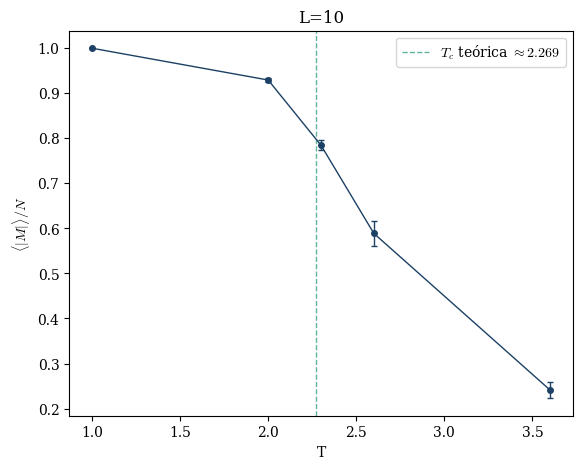

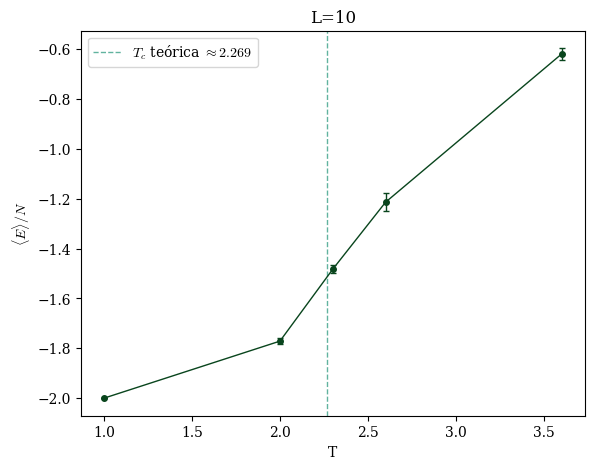

In [ ]:
def pasos_para_temperatura(T, T_c, base_termalizacion=n_termalizacion_demo, base_pasos=n_pasos_diagnostico):
    """
    Decide cuántos MCS de termalización y de muestreo usar según qué tan
    cerca esté T de T_c.
    """
    distancia = abs(T - T_c)
    factor = 1.0 + 2.0 * np.exp(-(distancia / 0.3) ** 2)
    return int(base_termalizacion * factor), int(base_pasos * factor)

""" Malla de temperaturas: densa cerca de T_c, más espaciada lejos de ella. """
T_lejos_baja = np.arange(1.0, 2.0, 1)
T_cerca = np.arange(2.0, 2.6, 0.3)
T_lejos_alta = np.arange(2.6, 4.0, 1)
temperaturas = np.unique(np.round(np.concatenate([T_lejos_baja, T_cerca, T_lejos_alta]), 3))

resultados_barrido = []
print("Barrido en temperatura:")
for T in temperaturas:
    n_term, n_pasos = pasos_para_temperatura(T, T_c)
    E_hist, M_hist, _ = simular(L=L, T=T, n_pasos=n_pasos, J=J, semilla=semilla)
    res = calcular_promedios(E_hist, M_hist, n_term, N)
    resultados_barrido.append({"T": T, **res, "n_termalizacion": n_term, "n_pasos": n_pasos})
    print(f'  T={T:5.3f} (n_term={n_term:5d}, n_pasos={n_pasos:5d})  '
          f'<E>/N={res["E_prom"]:8.4f}  <|M|>/N={res["M_abs_prom"]:7.4f}')
    
"""  Convertir los resultados del barrido en un DataFrame """
df_resultados_barrido = pd.DataFrame(resultados_barrido)

""" Guardar CSV los resultados del barrido  """
nombre_resultados_barrido = carpeta / f"Barrido_temperaturas-L={L}_sweep={n_pasos_diagnostico}.csv"
df_resultados_barrido.to_csv(nombre_resultados_barrido, index=False)

print(f"Resultados guardados en: {nombre_resultados_barrido}")

T_arr = np.array([r["T"] for r in resultados_barrido])
E_prom_arr = np.array([r["E_prom"] for r in resultados_barrido])
E_err_arr = np.array([r["E_err"] for r in resultados_barrido])
M_abs_prom_arr = np.array([r["M_abs_prom"] for r in resultados_barrido])
M_abs_err_arr = np.array([r["M_abs_err"] for r in resultados_barrido])

fig2, ax = plt.subplots(figsize=(6.5, 5))
ax.errorbar(T_arr, M_abs_prom_arr, yerr=M_abs_err_arr, fmt="o-", ms=4, lw=1, color="#1D4165", capsize=2)
ax.axvline(T_c, color="#61b39f", ls="--", lw=1, label=fr"$T_c$ teórica $\approx {T_c:.3f}$")
ax.set_xlabel("T")
ax.set_ylabel(r"$\langle |M| \rangle / N$")
ax.set_title(f"L={L}")
ax.legend()
plt.savefig(carpeta / f"Magnetizacion_L={L}_sweep={n_pasos_diagnostico}.png",
            bbox_inches="tight", dpi=300)
plt.show()

fig3, ax3 = plt.subplots(figsize=(6.5, 5))
ax3.errorbar(T_arr, E_prom_arr, yerr=E_err_arr, fmt="o-", ms=4, lw=1, color="#09451d", capsize=2) #"#31bc5f"
ax3.axvline(T_c, color="#61b39f", ls="--", lw=1, label=fr"$T_c$ teórica $\approx {T_c:.3f}$")
ax3.set_xlabel("T")
ax3.set_ylabel(r"$\langle E \rangle / N$")
ax3.set_title(f"L={L}")
ax3.legend()
plt.savefig( carpeta / f"Energia_L={L}_sweep={n_pasos_diagnostico}.png",
            bbox_inches="tight", dpi=300)
plt.show()